In [40]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


In [48]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression




In [ ]:

df =pd.read_csv(r"C:\Users\Hp\OneDrive\Attachments\Desktop\mlproject\linera\House Price Prediction Dataset.csv")

print(df.head())   # shows first 5 rows
print(df.info())   # shows column names and data types


   Id  Area  Bedrooms  Bathrooms  ...  Location  Condition Garage   Price
0   1  1360         5          4  ...  Downtown  Excellent     No  149919
1   2  4272         5          4  ...  Downtown  Excellent     No  424998
2   3  3592         2          2  ...  Downtown       Good     No  266746
3   4   966         4          2  ...  Suburban       Fair    Yes  244020
4   5  4926         1          4  ...  Downtown       Fair    Yes  636056

[5 rows x 10 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   obje

In [23]:
print('shape', df.shape)
print('columns', df.columns)

shape (2000, 10)
columns Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')


In [29]:
for columns in df.columns:
    print(df[columns].value_counts())
    print('***'*10)

Id
1984    1
1983    1
1982    1
1981    1
1980    1
       ..
5       1
4       1
3       1
2       1
1       1
Name: count, Length: 2000, dtype: int64
******************************
Area
4219    5
1752    4
4646    4
1516    4
1743    4
       ..
3592    1
1288    1
2747    1
3247    1
663     1
Name: count, Length: 1622, dtype: int64
******************************
Bedrooms
1    418
3    406
4    405
5    403
2    368
Name: count, dtype: int64
******************************
Bathrooms
3    524
4    521
2    494
1    461
Name: count, dtype: int64
******************************
Floors
2    691
1    661
3    648
Name: count, dtype: int64
******************************
YearBuilt
2005    27
2002    26
1901    25
1981    24
2000    23
        ..
2010    11
1944    10
1950     9
1994     7
2016     6
Name: count, Length: 124, dtype: int64
******************************
Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64
*************************

In [37]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [32]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

In [38]:
numerical = df.select_dtypes(include=["int64"]).columns
categorical = df.select_dtypes(include=["object"]).columns

print(f" We have features: {len(numerical)} numerical features {numerical}")
print(100 * ">")
print(f" We have features: {len(categorical)} categorical features {categorical}")

 We have features: 7 numerical features Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price'], dtype='object')
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
 We have features: 3 categorical features Index(['Location', 'Condition', 'Garage'], dtype='object')


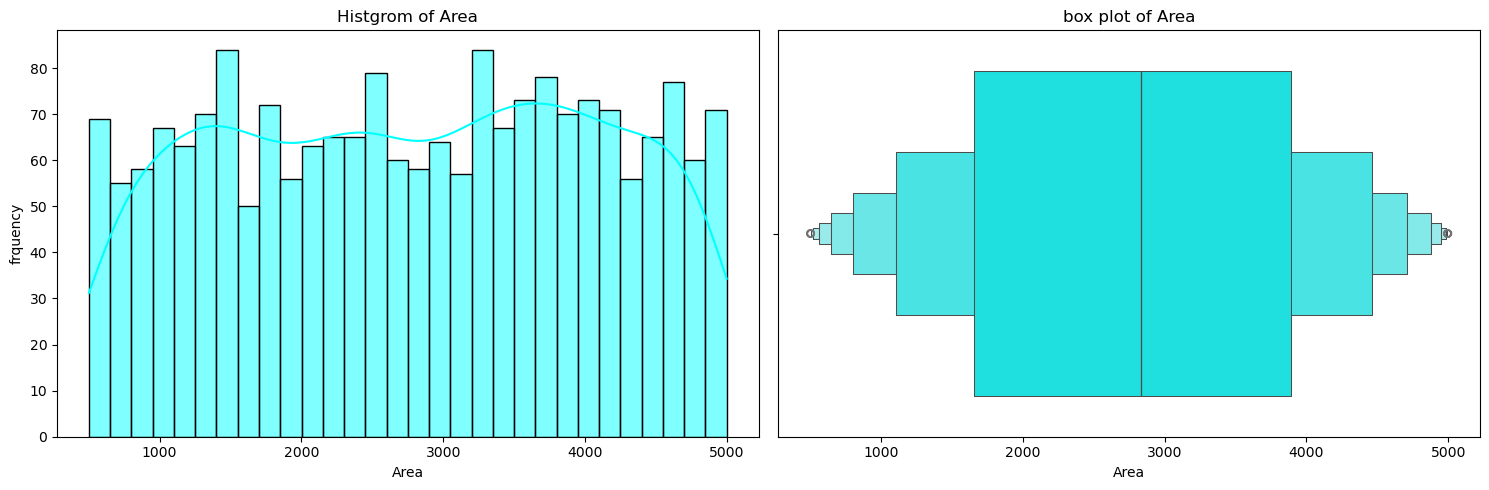

Number of Unique Area: 1622
Missing Values in Area: 0


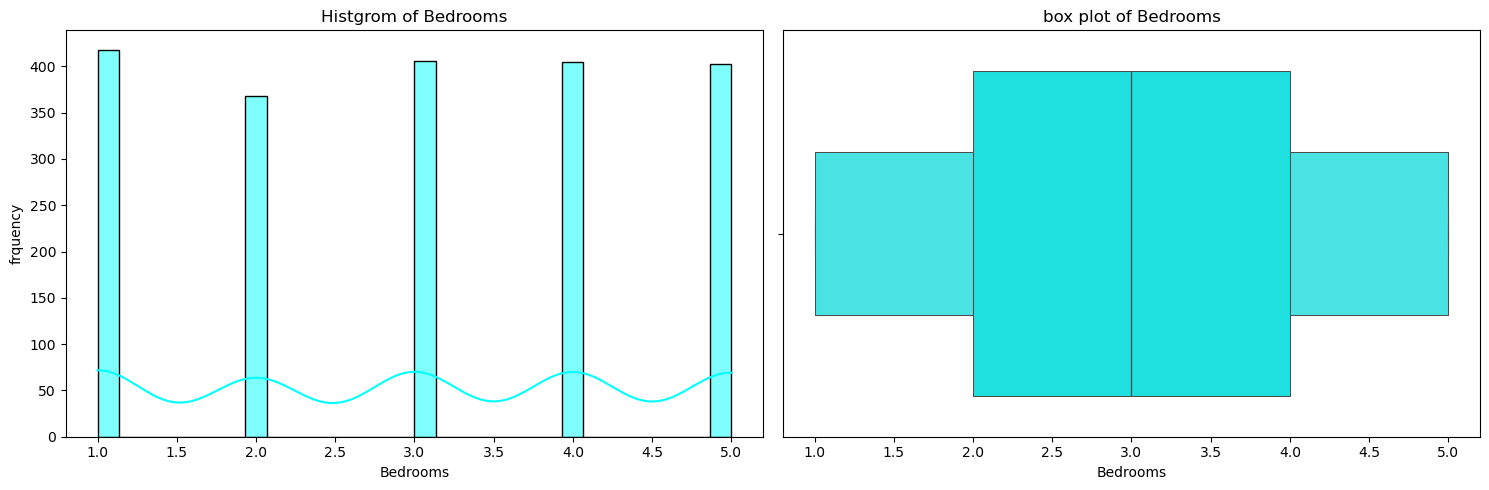

Number of Unique Bedrooms: 5
Missing Values in Bedrooms: 0


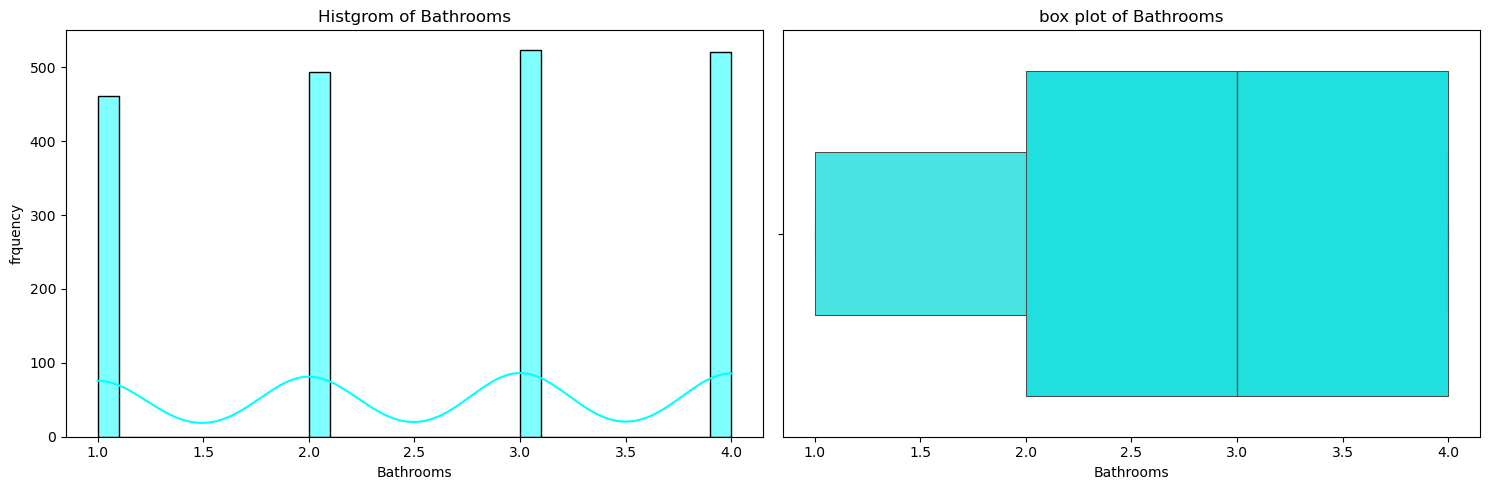

Number of Unique Bathrooms: 4
Missing Values in Bathrooms: 0


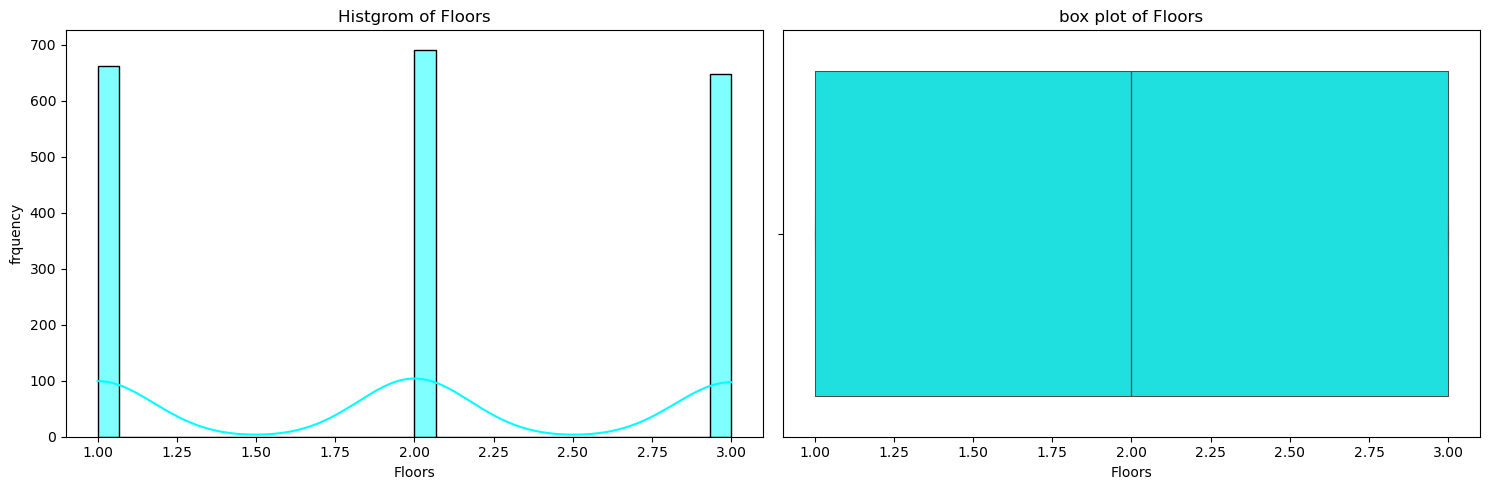

Number of Unique Floors: 3
Missing Values in Floors: 0


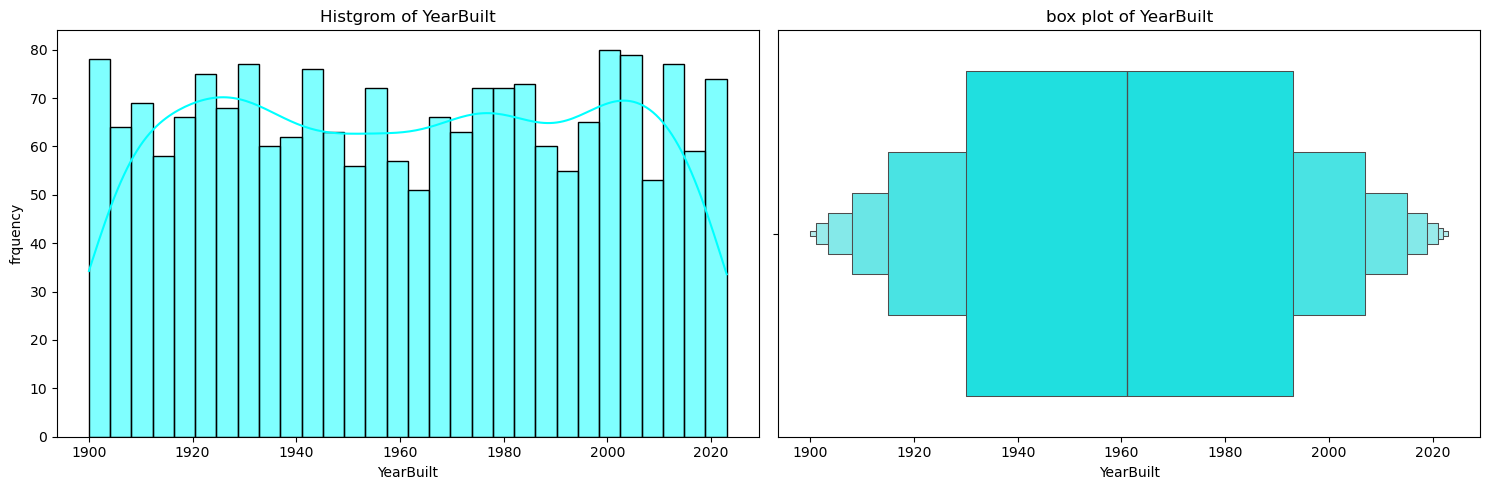

Number of Unique YearBuilt: 124
Missing Values in YearBuilt: 0


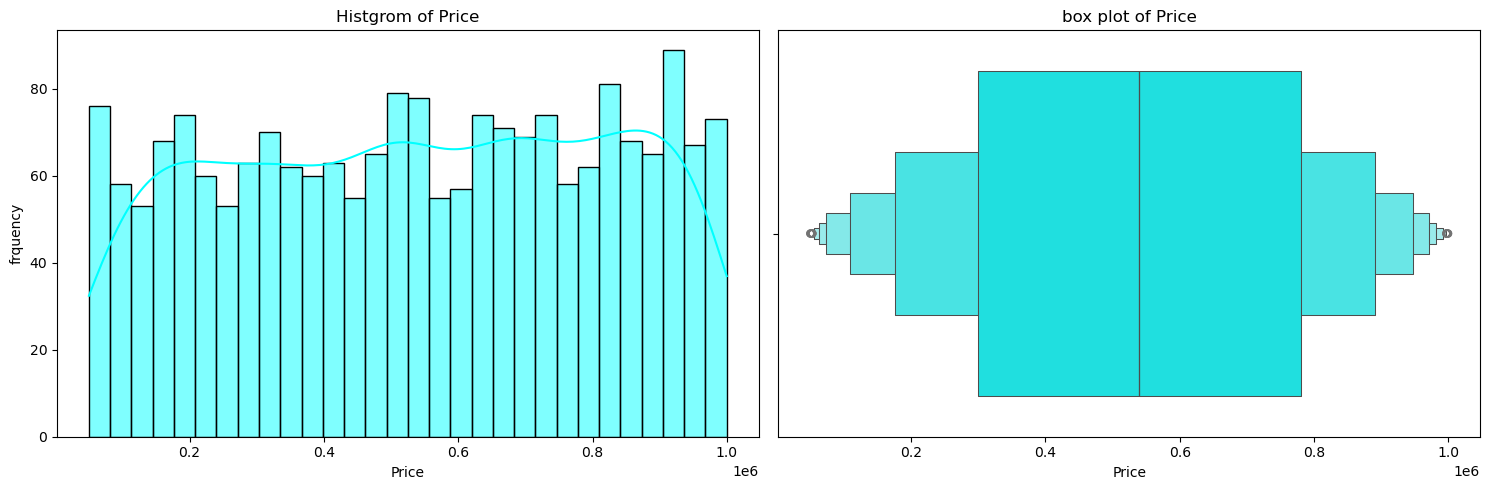

Number of Unique Price: 1999
Missing Values in Price: 0


In [41]:
numerical = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']

for col in numerical:
    plt.figure(figsize = (15,5))
    plt.subplot(1,2,1)
    sns.histplot(data = df, x = col, kde= True, bins = 30,color="cyan")
    plt.title(f"Histgrom of {col}")
    plt.xlabel(col)
    plt.ylabel("frquency")

    plt.subplot(1,2,2)
    sns.boxenplot(data = df, x=col, color ="cyan")
    plt.title(f"box plot of {col}")
    plt.tight_layout()
    plt.show()

        # Print unique and missing values
    print(f"Number of Unique {col}: {df[col].nunique()}")
    print(f"Missing Values in {col}: {df[col].isnull().sum()}")

C:\Users\Hp\AppData\Local\Temp\ipykernel_16056\3262215006.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = col, palette = "Set2")


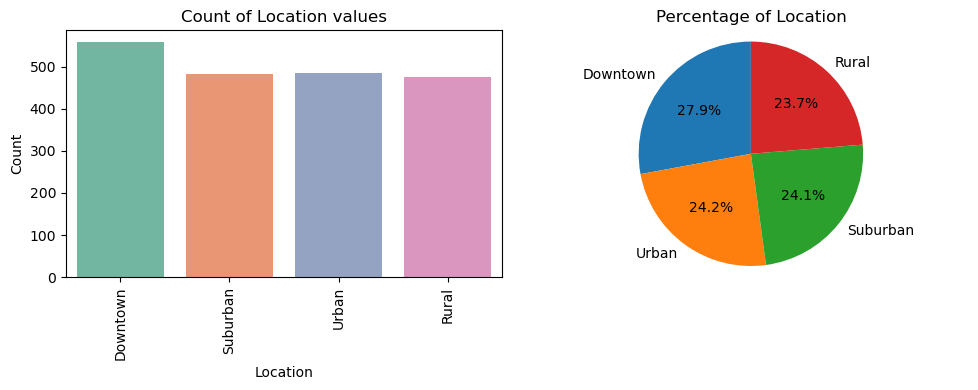

C:\Users\Hp\AppData\Local\Temp\ipykernel_16056\3262215006.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = col, palette = "Set2")


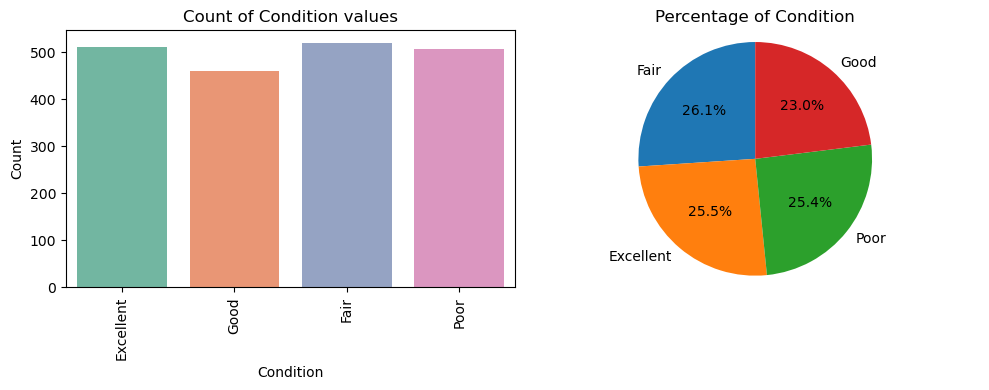

C:\Users\Hp\AppData\Local\Temp\ipykernel_16056\3262215006.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = col, palette = "Set2")


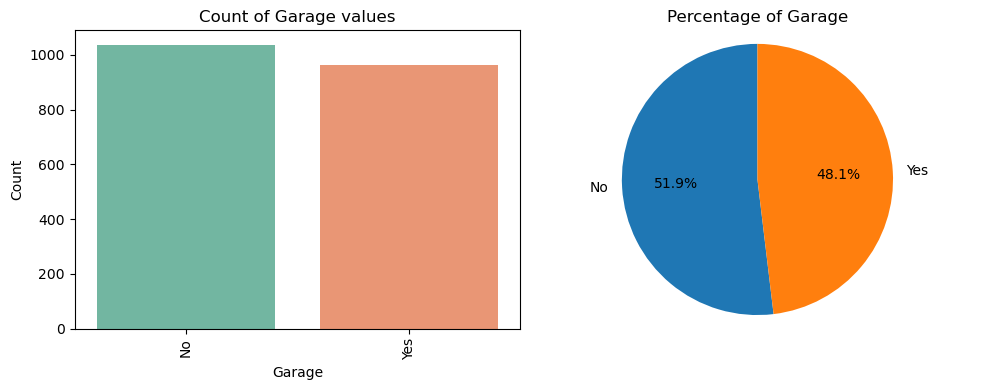

In [42]:
for col in ['Location', 'Condition', 'Garage']:
    counts = df[col].value_counts()
    plt.figure(figsize = (10,4))
    plt.subplot(1,2,1)
    sns.countplot(data = df, x = col, palette = "Set2")
    plt.title(f"Count of {col} values")
    plt.xticks(rotation = 90)
    plt.ylabel("Count")
    # plt.show()

    plt.subplot(1,2,2)
    plt.pie(counts,labels = counts.index,autopct = "%1.1f%%",startangle=90)
    plt.title(f"Percentage of {col}")
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

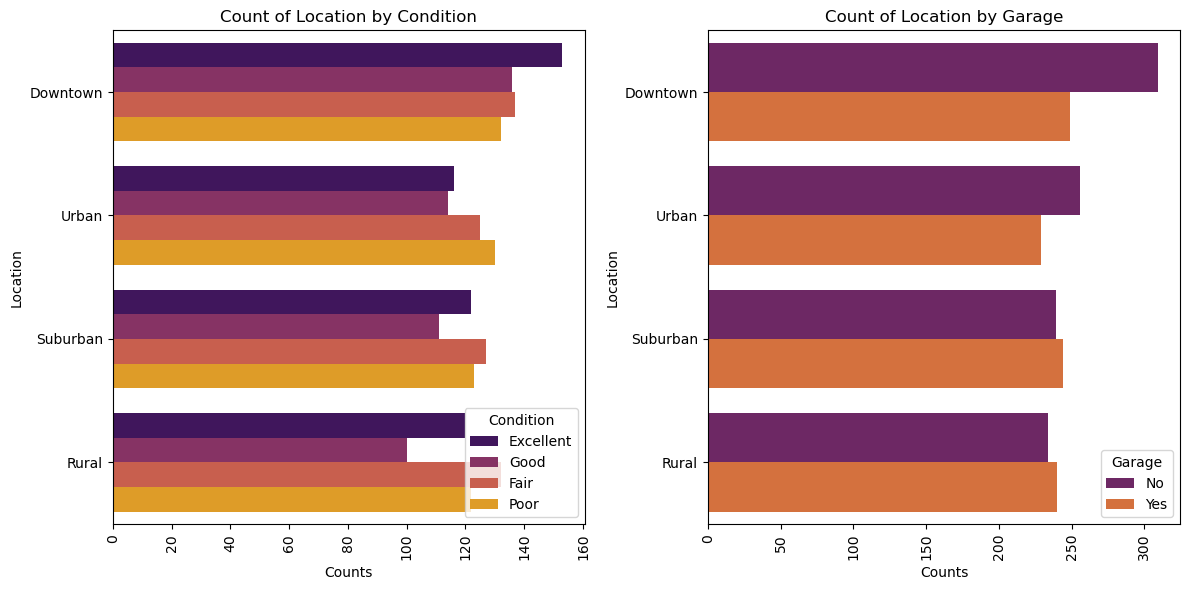

In [43]:
# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Count of Location by Condition
sns.countplot(data=df, y="Location", order=df["Location"].value_counts().index, hue="Condition", palette="inferno", ax=axs[0])
axs[0].set_title("Count of Location by Condition")
axs[0].set_xlabel("Counts")
axs[0].set_ylabel("Location")
axs[0].tick_params(axis='x', rotation=90)

# Subplot 2: Count of Location by Garage
sns.countplot(data=df, y="Location", order=df["Location"].value_counts().index, hue="Garage", palette="inferno", ax=axs[1])
axs[1].set_title("Count of Location by Garage")
axs[1].set_xlabel("Counts")
axs[1].set_ylabel("Location")
axs[1].tick_params(axis='x', rotation=90)

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

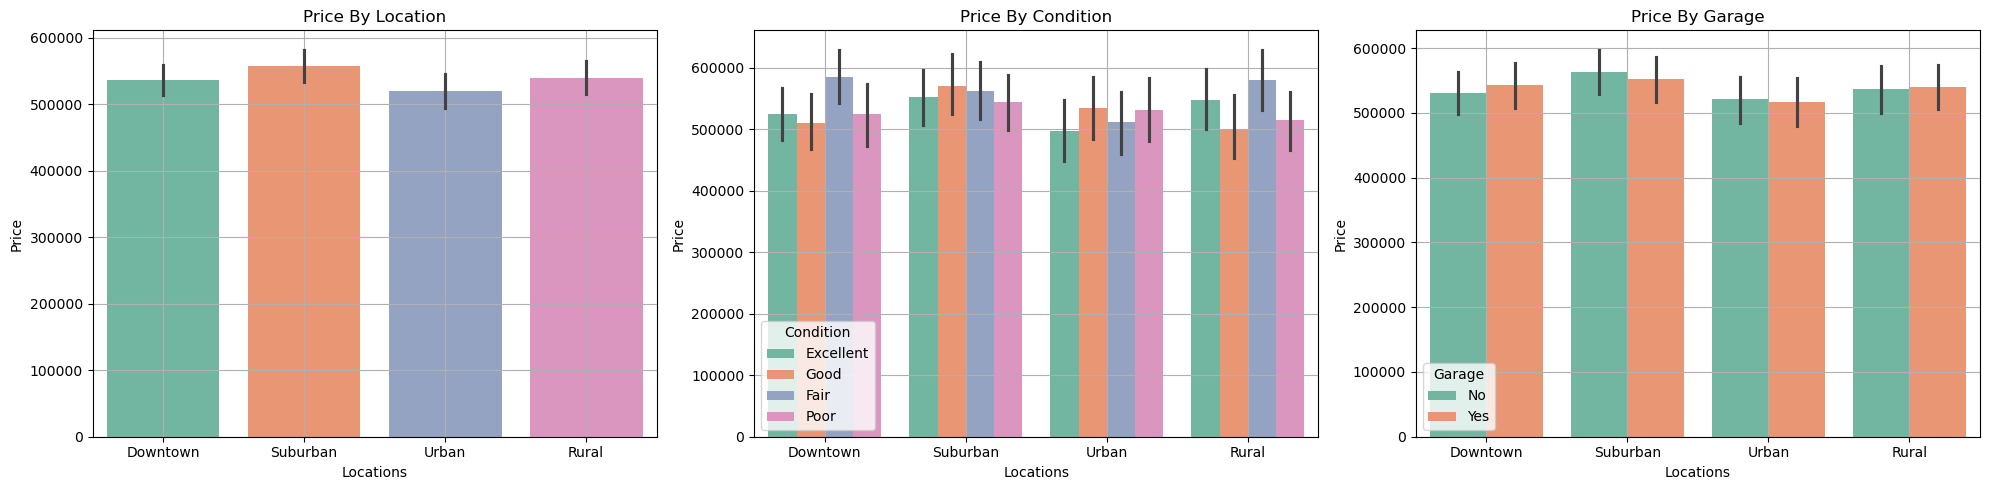

In [44]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)
sns.barplot(data=df, x="Location", y="Price", hue="Location", palette="Set2")
plt.title("Price By Location")
plt.xlabel("Locations")
plt.ylabel("Price")
plt.grid()

plt.subplot(1,3,2)
sns.barplot(data=df, x="Location", y="Price", hue="Condition", palette="Set2")
plt.title("Price By Condition")
plt.xlabel("Locations")
plt.ylabel("Price")
plt.grid()

plt.subplot(1,3,3)
sns.barplot(data=df, x="Location", y="Price", hue="Garage", palette="Set2")
plt.title("Price By Garage")
plt.xlabel("Locations")
plt.ylabel("Price")
plt.grid()

plt.tight_layout()
plt.show()

model traning 

In [45]:
X =df.drop("Price", axis = 1)
Y =df["Price"]

In [46]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [50]:
numerical =X.select_dtypes(include=["int64"]).columns.tolist()
categorical =X.select_dtypes(include=["object"]).columns.tolist()

print(numerical)
print(categorical)

['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
['Location', 'Condition', 'Garage']


In [52]:
# Create a pipeline for numerical features
numerical_transformer = make_pipeline(
    RobustScaler()
)
# Create a pipeline for categorical features
categorical_transformer = make_pipeline(
    OneHotEncoder(handle_unknown='ignore')
)

# Combine transformers into a preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical),
        ('cat', categorical_transformer, categorical)
    ]
)


In [54]:
# Build the full pipeline with preprocessing and model
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("DecisionTree", DecisionTreeRegressor(random_state=42, max_depth=5, min_samples_split=10))
])

# Fit the pipeline to the training data
pipeline.fit(X_train, Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('robustscaler',
                                                                   RobustScaler())]),
                                                  ['Id', 'Area', 'Bedrooms',
                                                   'Bathrooms', 'Floors',
                                                   'YearBuilt']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Location', 'Condition',
                                                   'Garage'])])),
                ('DecisionTree',
                 DecisionTreeRegressor(max_depth=5, min_samples_split=10,
                                       random_state=42))])

In [58]:
# Predict and evaluate
y_pred = pipeline.predict(X_test)
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)
y_pred = pipeline.predict(X_test)
print("Mean Squared Error:", mse.__round__(2))
print("Mean Absolute Error:", mae.__round__(2))
print("R-squared:", r2.__round__(2))

Mean Squared Error: 78279764120.86
Mean Absolute Error: 242867.45
R-squared: -0.01


In [59]:
# Build the full pipeline with preprocessing and model
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("linear", LinearRegression())
])

# Fit the pipeline to the training data
pipeline.fit(X_train, Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('robustscaler',
                                                                   RobustScaler())]),
                                                  ['Id', 'Area', 'Bedrooms',
                                                   'Bathrooms', 'Floors',
                                                   'YearBuilt']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Location', 'Condition',
                                                   'Garage'])])),
                ('linear', LinearRegression())])

In [60]:
# Predict and evaluate
y_pred = pipeline.predict(X_test)
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)
y_pred = pipeline.predict(X_test)
print("Mean Squared Error:", mse.__round__(2))
print("Mean Absolute Error:", mae.__round__(2))
print("R-squared:", r2.__round__(2))

Mean Squared Error: 78279764120.86
Mean Absolute Error: 242867.45
R-squared: -0.01
